# Dreambooth

In [ ]:
!git clone https://github.com/huggingface/diffusers
!cd diffusers && pip install .
!pip install xformers bitsandbytes

Cloning into 'diffusers'...
remote: Enumerating objects: 116310, done.
remote: Counting objects: 100% (761/761), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 116310 (delta 671), reused 541 (delta 535), pack-reused 115549 (from 4)
Receiving objects: 100% (116310/116310), 89.12 MiB | 10.23 MiB/s, done.
Resolving deltas: 100% (86885/86885), done.
Processing /content/diffusers
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.37.0.dev0-py3-none-any.whl size=4830827 sha256=b407d4db47b9abe56364037d6cdd42f25582dbfb9ee1a2639b9b108d88effde9
  Stored in directory: /tmp/pip-ephem-wheel-cache-isufwrlm/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0
    Uninstalling diffusers-0.36.0:
      Successfully uninst

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

alvan-nee-brFsZ7qszSY-unsplash.jpeg:   0%|          | 0.00/1.19M [00:00<?, ?B/s]

alvan-nee-9M0tSjb-cpA-unsplash.jpeg:   0%|          | 0.00/677k [00:00<?, ?B/s]

alvan-nee-Id1DBHv4fbg-unsplash.jpeg:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

alvan-nee-eoqnr8ikwFE-unsplash.jpeg:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

alvan-nee-bQaAJCbNq3g-unsplash.jpeg:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

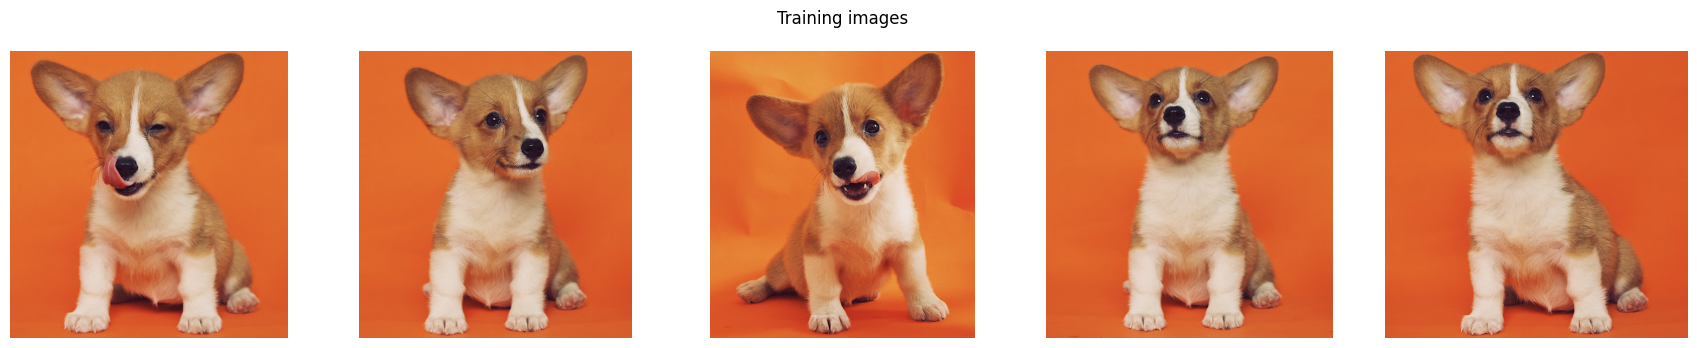

In [2]:
from huggingface_hub import snapshot_download
from PIL import Image
import matplotlib.pyplot as plt
import os

local_dir = "./dog"
snapshot_download(
    "diffusers/dog-example",
    local_dir=local_dir,
    repo_type="dataset",
    ignore_patterns=".gitattributes",
)

data_dir = "/content/dog"
filelist = os.listdir(data_dir)
filelist = [f for f in filelist if f.endswith(".jpeg")]
fig, ax = plt.subplots(1, len(filelist), figsize=(len(filelist) * 3.5, 3.5))
for n, img in enumerate(filelist):
    img = Image.open(os.path.join(data_dir, img))
    ax[n].axis("off")
    ax[n].imshow(img)
fig.suptitle("Training images")
plt.tight_layout()
plt.show()

In [5]:
!rm -rf /content/dog/.cache

In [ ]:
os.environ["MODEL_NAME"] = "stable-diffusion-v1-5/stable-diffusion-v1-5"
os.environ["INSTANCE_DIR"] = "/content/dog"
os.environ["OUTPUT_DIR"] = "/content/dreambooth_model_output"

!accelerate launch /content/diffusers/examples/dreambooth/train_dreambooth.py \
  --use_8bit_adam \
  --gradient_checkpointing \
  --enable_xformers_memory_efficient_attention \
  --set_grads_to_none \
  --pretrained_model_name_or_path=$MODEL_NAME  \
  --instance_data_dir=$INSTANCE_DIR \
  --instance_prompt="a photo of a sks dog" \
  --output_dir=$OUTPUT_DIR \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=400

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-01-09 13:38:08.257276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767965888.283340    6599 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767965888.297072    6599 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767965888.315842    6599 computation_plac

Training time: 21 minutes

In [ ]:
!zip -r /content/drive/MyDrive/dreambooth_model_output.zip /content/dreambooth_model_output

  adding: content/dreambooth_model_output/ (stored 0%)
  adding: content/dreambooth_model_output/model_index.json (deflated 57%)
  adding: content/dreambooth_model_output/tokenizer/ (stored 0%)
  adding: content/dreambooth_model_output/tokenizer/merges.txt (deflated 60%)
  adding: content/dreambooth_model_output/tokenizer/vocab.json (deflated 71%)
  adding: content/dreambooth_model_output/tokenizer/tokenizer_config.json (deflated 63%)
  adding: content/dreambooth_model_output/tokenizer/special_tokens_map.json (deflated 73%)
  adding: content/dreambooth_model_output/vae/ (stored 0%)
  adding: content/dreambooth_model_output/vae/diffusion_pytorch_model.safetensors (deflated 7%)
  adding: content/dreambooth_model_output/vae/config.json (deflated 56%)
  adding: content/dreambooth_model_output/unet/ (stored 0%)
  adding: content/dreambooth_model_output/unet/diffusion_pytorch_model.safetensors

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access '__iter__' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):





zip error: Interrupted (aborting)



In [ ]:
from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel
import torch

unet = UNet2DConditionModel.from_pretrained("/content/dreambooth_model_output/unet")

# if you have trained with `--args.train_text_encoder` make sure to also load the text encoder
text_encoder = CLIPTextModel.from_pretrained("/content/dreambooth_model_output/text_encoder")

pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", unet=unet, text_encoder=text_encoder, dtype=torch.float16,
).to("cuda")

prompts = ["A picture of a sks dog laying on a couch", "A picture of a sks dog in crochet style", "A picture of a sks dog in a grocery store aisle"]
for n, prompt in enumerate(prompts):
    image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5, generator=torch.manual_seed(0)).images[0]
    image.save(f"sks_style_image_dreambooth_{n}.png")

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
).to("cuda")

for n, prompt in enumerate(prompts):
    image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5, generator=torch.manual_seed(0)).images[0]
    image.save(f"sks_style_image_{n}.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

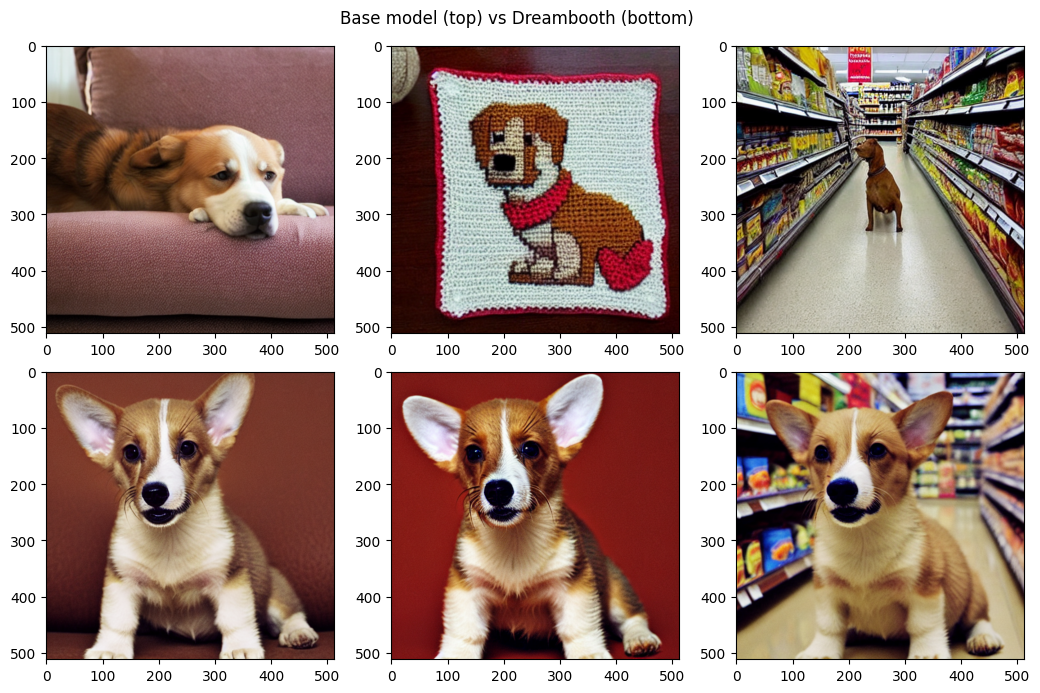

In [ ]:
data_dir = "/content/"
fig, ax = plt.subplots(2, 3, figsize=(3 * 3.5, 7))
for n in range(len(prompts)):
    img_orig = Image.open(data_dir + f"sks_style_image_{n}.png")
    img_dreambooth = Image.open(data_dir + f"sks_style_image_dreambooth_{n}.png")
    ax[0, n].imshow(img_orig)
    ax[1, n].imshow(img_dreambooth)
fig.suptitle("Base model (top) vs Dreambooth (bottom)")
plt.tight_layout()
plt.show()

# LoRA

In [1]:
!git clone https://github.com/huggingface/peft
!cd peft && pip install -r requirements.txt
!cd peft && pip install git+https://github.com/huggingface/peft

Cloning into 'peft'...
remote: Enumerating objects: 14639, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 14639 (delta 120), reused 52 (delta 50), pack-reused 14443 (from 3)
Receiving objects: 100% (14639/14639), 24.69 MiB | 6.16 MiB/s, done.
Resolving deltas: 100% (10113/10113), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 9.4 MB/s eta 0:00:00
  Cloning https://github.com/huggingface/peft to /tmp/pip-req-build-7670oag2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft /tmp/pip-req-build-7670oag2
  Resolved https://github.com/huggingface/peft to commit 8be1a16f5e06ca5e197d2af74bdfc5b3c8072d26
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peft: filename=peft-0.18.1.dev0-py3-none-any.whl size=584827 sha256=519a15f002d42980a0204050d36a6d9ceb185da6aa957f

In [6]:
import os
os.environ["MODEL_NAME"] = "stable-diffusion-v1-5/stable-diffusion-v1-5"
os.environ["INSTANCE_DIR"] = "/content/dog"
os.environ["OUTPUT_DIR"] = "/content/model_lora_output"

!accelerate launch /content/peft/examples/lora_dreambooth/train_dreambooth.py \
  --pretrained_model_name_or_path=$MODEL_NAME  \
  --instance_data_dir=$INSTANCE_DIR \
  --output_dir=$OUTPUT_DIR \
  --train_text_encoder \
  --num_dataloader_workers=1 \
  --instance_prompt="a photo of sks dog" \
  --resolution=512 \
  --train_batch_size=1 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --use_lora \
  --lora_r 16 \
  --lora_alpha 27 \
  --lora_text_encoder_r 16 \
  --lora_text_encoder_alpha 17 \
  --learning_rate=1e-4 \
  --gradient_accumulation_steps=1 \
  --gradient_checkpointing \
  --max_train_steps=800

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-01-10 15:27:01.641095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768058821.661075    1621 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768058821.667131    1621 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768058821.682339    1621 computation_plac

Training time: 20 mins, but 2x more steps performed.

In [11]:
import torch
from peft import LoraConfig, PeftModel
from diffusers import StableDiffusionPipeline

def get_lora_sd_pipeline(
    ckpt_dir, base_model_name_or_path=None, dtype=torch.float16, device="cuda", adapter_name="default"
):
    unet_sub_dir = os.path.join(ckpt_dir, "unet")
    text_encoder_sub_dir = os.path.join(ckpt_dir, "text_encoder")
    if os.path.exists(text_encoder_sub_dir) and base_model_name_or_path is None:
        config = LoraConfig.from_pretrained(text_encoder_sub_dir)
        base_model_name_or_path = config.base_model_name_or_path

    if base_model_name_or_path is None:
        raise ValueError("Please specify the base model name or path")

    pipe = StableDiffusionPipeline.from_pretrained(base_model_name_or_path, torch_dtype=dtype).to(device)
    pipe.unet = PeftModel.from_pretrained(pipe.unet, unet_sub_dir, adapter_name=adapter_name)

    if os.path.exists(text_encoder_sub_dir):
        pipe.text_encoder = PeftModel.from_pretrained(
            pipe.text_encoder, text_encoder_sub_dir, adapter_name=adapter_name
        )

    if dtype in (torch.float16, torch.bfloat16):
        pipe.unet.half()
        pipe.text_encoder.half()

    pipe.to(device)
    return pipe

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [15]:
from pathlib import Path

pipeline = get_lora_sd_pipeline(Path("/content/model_lora_output_sks_dog"), adapter_name="dog")

prompts = ["A picture of a sks dog laying on a couch", "A picture of a sks dog in crochet style", "A picture of a sks dog in a grocery store aisle"]
for n, prompt in enumerate(prompts):
    image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5, generator=torch.manual_seed(10)).images[0]
    image.save(f"sks_style_image_lora_{n}.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [17]:
from diffusers import DiffusionPipeline

pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
).to("cuda")

for n, prompt in enumerate(prompts):
    image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5, generator=torch.manual_seed(10)).images[0]
    image.save(f"sks_style_image_{n}.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

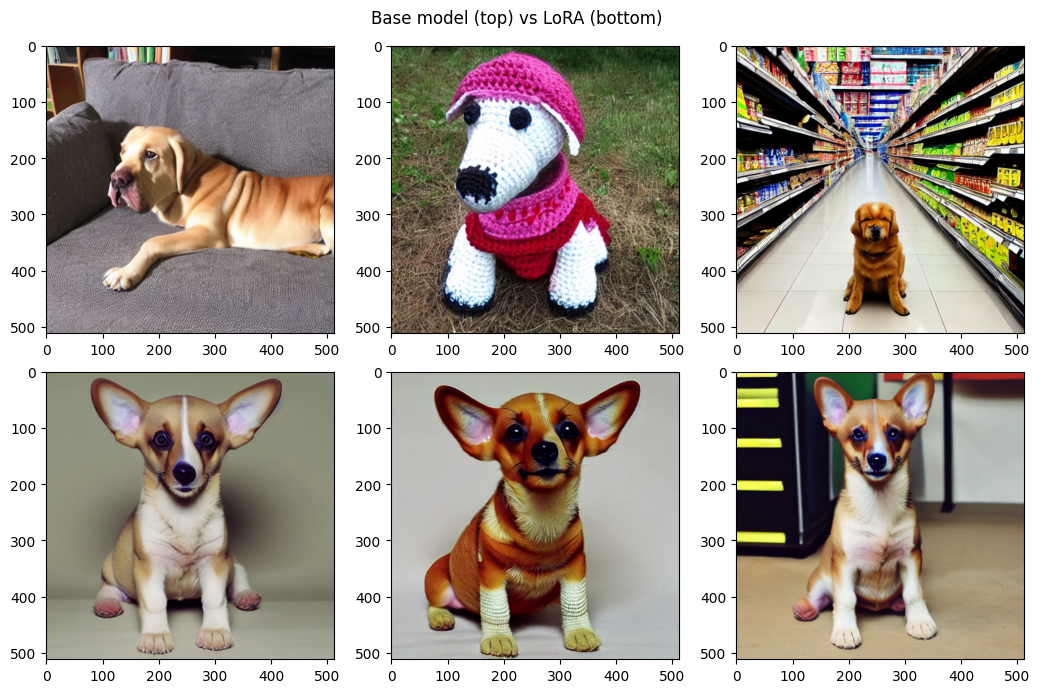

In [18]:
data_dir = "/content/"
fig, ax = plt.subplots(2, 3, figsize=(3 * 3.5, 7))
for n in range(len(prompts)):
    img_orig = Image.open(data_dir + f"sks_style_image_{n}.png")
    img_lora = Image.open(data_dir + f"sks_style_image_lora_{n}.png")
    ax[0, n].imshow(img_orig)
    ax[1, n].imshow(img_lora)
fig.suptitle("Base model (top) vs LoRA (bottom)")
plt.tight_layout()
plt.show()

In [20]:
!zip -r /content/drive/MyDrive/lora_dog_exp_1_model_output.zip /content/model_lora_output_sks_dog/

  adding: content/model_lora_output_sks_dog/ (stored 0%)
  adding: content/model_lora_output_sks_dog/unet/ (stored 0%)
  adding: content/model_lora_output_sks_dog/unet/adapter_config.json (deflated 56%)
  adding: content/model_lora_output_sks_dog/unet/README.md (deflated 66%)
  adding: content/model_lora_output_sks_dog/unet/adapter_model.safetensors (deflated 7%)
  adding: content/model_lora_output_sks_dog/logs/ (stored 0%)
  adding: content/model_lora_output_sks_dog/logs/dreambooth/ (stored 0%)
  adding: content/model_lora_output_sks_dog/logs/dreambooth/1768058770.630104/ (stored 0%)
  adding: content/model_lora_output_sks_dog/logs/dreambooth/1768058770.630104/hparams.yml (deflated 55%)
  adding: content/model_lora_output_sks_dog/logs/dreambooth/1768058843.1938598/ (stored 0%)
  adding: content/model_lora_output_sks_dog/logs/dreambooth/1768058843.1938598/events.out.tfevents.1768058843.9ad91d49e0c7.1621.1 (deflated 58%)
  adding: content/model_lora_output_sks_dog/logs/dreambooth/176805